# **Analyse des résultats**


**Analyse de l'entrainement de modèle, et analyse des métriques issues de la meilleure epoch**


## **Librairies**

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import os

import pandas as pd
import numpy as np
import json
import re
import math

## **0. Chargement des fichiers résultat**

**Deux options** :
 
 - **1 :** utiliser les fichiers générés à partir de la pipeline **entrainement de modèle**

 Cette option permet d'analyser les données liées à l'entrainement + les métriques liées au meileur modèle retenu 

 - **2 :** à partir d'un fichier _**modele.path**_, générer les fichiers de résultats liées aux performances du modèle (donc pas d'informations sur l'entrainement)

**Noms des fichiers/dossiers résultats**

In [97]:
# noms des dossiers de résultats
resultats_folder_name_ref = "ResnetFineTune_temp_17h27"
resultats_folder_name_2 = "ResnetFineTune_temp_17h27"
   

**Loading des données**

In [98]:

resultats1_path = os.path.join("..", "results", resultats_folder_name_ref)
resultats2_path = os.path.join("..", "results", resultats_folder_name_2)

In [99]:


def json_to_training_df(json_path_or_obj):
    """
    Transforme un training_monitor JSON en DataFrame avec colonnes :
    epoch, train_loss, train_acc, train_precision, train_recall, train_f1_macro,
    val_loss, val_acc, val_precision, val_recall, val_f1_macro
    
    Args:
        json_path_or_obj (str ou dict) : chemin vers le fichier JSON ou dictionnaire JSON chargé.
    
    Returns:
        pd.DataFrame
    """
    
    # Charger le JSON si c'est un chemin
    if isinstance(json_path_or_obj, str):
        with open(json_path_or_obj, "r") as f:
            data = json.load(f)
    else:
        data = json_path_or_obj
    
    rows = []
    
    for epoch, entries in data.items():
        row = {
            "epoch": int(epoch),
            "train_loss": None,
            "train_acc": None,
            "train_precision": None,
            "train_recall": None,
            "train_f1_macro": None,
            "val_loss": None,
            "val_acc": None,
            "val_precision": None,
            "val_recall": None,
            "val_f1_macro": None
        }
        
        for entry in entries:
            mode = entry["mode"]
            precision_macro = np.mean(entry["precision_per_class"])
            recall_macro = np.mean(entry["recall_per_class"])
            
            if mode == "train":
                row["train_loss"] = entry.get("loss")
                row["train_acc"] = entry["accuracy"]
                row["train_precision"] = precision_macro
                row["train_recall"] = recall_macro
                row["train_f1_macro"] = entry["f1_macro"]
            elif mode == "val":
                row["val_loss"] = entry.get("loss")
                row["val_acc"] = entry["accuracy"]
                row["val_precision"] = precision_macro
                row["val_recall"] = recall_macro
                row["val_f1_macro"] = entry["f1_macro"]
        
        rows.append(row)
    
    df = pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)
    return df

In [100]:
def json_to_class_metrics_df(json_path_or_obj, epoch=None):
    """
    Transforme un training_monitor JSON en DataFrame par classe avec colonnes :
    class, train_accuracy, train_precision, train_recall, train_f1_score,
    val_accuracy, val_precision, val_recall, val_f1_score
    
    Args:
        json_path_or_obj (str ou dict) : chemin vers le fichier JSON ou dictionnaire JSON chargé.
        epoch (int, optional) : epoch à extraire. Si None, prend la dernière epoch.
    
    Returns:
        pd.DataFrame
    """
    
    # Charger le JSON si c'est un chemin
    if isinstance(json_path_or_obj, str):
        with open(json_path_or_obj, "r") as f:
            data = json.load(f)
    else:
        data = json_path_or_obj
    
    # Choisir l'epoch
    if epoch is None:
        epoch_key = max(map(int, data.keys()))
    else:
        epoch_key = epoch
    
    entries = data[str(epoch_key)]
    
    # Récupérer le nombre de classes depuis train ou val
    for e in entries:
        if e["mode"] == "train":
            num_classes = len(e["f1_per_class"])
            break
    
    df = pd.DataFrame({
        "class": list(range(num_classes)),
        "train_accuracy": np.nan,
        "train_precision": np.nan,
        "train_recall": np.nan,
        "train_f1_score": np.nan,
        "val_accuracy": np.nan,
        "val_precision": np.nan,
        "val_recall": np.nan,
        "val_f1_score": np.nan
    })
    
    for entry in entries:
        mode = entry["mode"]
        if mode == "train":
            df["train_accuracy"] = [entry["accuracy"]] * num_classes
            df["train_precision"] = entry["precision_per_class"]
            df["train_recall"] = entry["recall_per_class"]
            df["train_f1_score"] = entry["f1_per_class"]
        elif mode == "val":
            df["val_accuracy"] = [entry["accuracy"]] * num_classes
            df["val_precision"] = entry["precision_per_class"]
            df["val_recall"] = entry["recall_per_class"]
            df["val_f1_score"] = entry["f1_per_class"]
    
    return df

In [101]:

def get_best_epoch(results_folder, pattern="best_model_epoch_(\d+).pth"):
    """
    Récupère l'entier le plus grand des fichiers best_model_epoch_n.pth
    dans le dossier results_folder.
    
    Args:
        results_folder (str): chemin vers le dossier contenant les fichiers.
        pattern (str): regex pour extraire l'epoch.
        
    Returns:
        int: le plus grand numéro d'epoch trouvé, ou None si aucun fichier.
    """
    best_epoch = None
    for f in os.listdir(results_folder):
        m = re.match(pattern, f)
        if m:
            epoch_num = int(m.group(1))
            if best_epoch is None or epoch_num > best_epoch:
                best_epoch = epoch_num
    return best_epoch

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_43978/2750586451.py:1: SyntaxWarning: invalid escape sequence '\d'
  def get_best_epoch(results_folder, pattern="best_model_epoch_(\d+).pth"):


In [102]:
df_log1 = json_to_training_df(os.path.join(resultats1_path, "training_monitor.json"))
df_log2 = json_to_training_df(os.path.join(resultats2_path, "training_monitor.json"))

df_confusion_matrix1 = pd.read_csv(os.path.join(resultats1_path, "confusion_matrix_epoch_0.csv"))
df_confusion_matrix2 = pd.read_csv(os.path.join(resultats2_path, "confusion_matrix_epoch_0.csv"))

best_epoch_modele_1 = get_best_epoch(resultats1_path, pattern="best_model_epoch_(\d+).pth")
best_epoch_modele_2 = get_best_epoch(resultats2_path, pattern="best_model_epoch_(\d+).pth")

df_metrics_per_class1 = json_to_class_metrics_df(os.path.join(resultats1_path, "training_monitor.json"), epoch=best_epoch_modele_1)
df_metrics_per_class2 = json_to_class_metrics_df(os.path.join(resultats2_path, "training_monitor.json"), epoch=best_epoch_modele_2)



<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_43978/3401389859.py:7: SyntaxWarning: invalid escape sequence '\d'
  best_epoch_modele_1 = get_best_epoch(resultats1_path, pattern="best_model_epoch_(\d+).pth")
/tmp/ipykernel_43978/3401389859.py:8: SyntaxWarning: invalid escape sequence '\d'
  best_epoch_modele_2 = get_best_epoch(resultats2_path, pattern="best_model_epoch_(\d+).pth")


**Upload des metrics par classe**

In [103]:

def json_to_class_metrics_all_epochs(json_path):
    """
    Transforme un training_monitor.json en DataFrame avec une ligne par epoch et par classe
    et les colonnes train_f1_score et val_f1_score.
    """
    with open(json_path, 'r') as f:
        monitor = json.load(f)
    
    rows = []
    
    for epoch_str, metrics_list in monitor.items():
        epoch = int(epoch_str)
        
        # On crée un dictionnaire pour stocker les f1 par classe pour ce epoch
        f1_train = None
        f1_val = None
        
        for metrics in metrics_list:
            if metrics['mode'] == 'train':
                f1_train = metrics['f1_per_class']
            elif metrics['mode'] == 'val':
                f1_val = metrics['f1_per_class']
        
        num_classes = len(f1_train) if f1_train else len(f1_val)
        
        for cls in range(num_classes):
            rows.append({
                'epoch': epoch,
                'class': cls,
                'train_f1_score': f1_train[cls] if f1_train else None,
                'val_f1_score': f1_val[cls] if f1_val else None
            })
    
    df = pd.DataFrame(rows)
    return df

# Exemple d'utilisation


In [104]:
df_metrics_per_class_per_epoch_1 = json_to_class_metrics_all_epochs(os.path.join(resultats1_path, "training_monitor.json"))
df_metrics_per_class_per_epoch_2 = json_to_class_metrics_all_epochs(os.path.join(resultats2_path, "training_monitor.json"))

print(df_metrics_per_class_per_epoch_1.head())

   epoch  class  train_f1_score  val_f1_score
0      0      0        0.000000      0.000000
1      0      1        0.000000      0.000000
2      0      2        0.362369      0.576087
3      0      3        0.000000      0.000000
4      0      4        0.000000      0.000000


**Informations sur les modèles**

In [105]:

# Charger les deux fichiers JSON
with open(os.path.join(resultats1_path, "training_summary.json"), "r") as f:
    info1 = json.load(f)

with open(os.path.join(resultats2_path, "training_summary.json"), "r") as f:
    info2 = json.load(f)

# Fonction pour comparer deux configs
def compare_model_info(info1, info2):
    print(f"{'Paramètre':<25} | {'Modèle 1':<25} | {'Modèle 2':<25}")
    print("-"*85)
    
    # Modèle
    print(f"{'Architecture':<25} | {info1['model']['architecture']:<25} | {info2['model']['architecture']:<25}")
    print(f"{'Total params':<25} | {info1['model']['total_params']:<25} | {info2['model']['total_params']:<25}")
    print(f"{'Trainable params':<25} | {info1['model']['trainable_params']:<25} | {info2['model']['trainable_params']:<25}")
    
    # Training config
    cfg_keys = ['batch_size','num_epochs','learning_rate','device','dropout']
    for k in cfg_keys:
        print(f"{k:<25} | {info1['training_config'][k]!s:<25} | {info2['training_config'][k]!s:<25}")
    
    # Optimizer
    opt_keys = ['type','lr','weight_decay','betas','eps']
    for k in opt_keys:
        print(f"Optimizer {k:<18} | {info1['optimizer'][k]!s:<25} | {info2['optimizer'][k]!s:<25}")
    
    # Scheduler
    print(f"{'Scheduler':<25} | {info1['scheduler']:<25} | {info2['scheduler']:<25}")
    
    # Criterion
    crit_keys = ['type','label_smoothing']
    for k in crit_keys:
        print(f"Criterion {k:<18} | {info1['criterion'][k]!s:<25} | {info2['criterion'][k]!s:<25}")

# Comparer les deux JSON
compare_model_info(info1, info2)

Paramètre                 | Modèle 1                  | Modèle 2                 
-------------------------------------------------------------------------------------
Architecture              | ResnetFineTune            | ResnetFineTune           
Total params              | 11202162                  | 11202162                 
Trainable params          | 11202162                  | 11202162                 
batch_size                | 32                        | 32                       
num_epochs                | 25                        | 25                       
learning_rate             | 0.0001                    | 0.0001                   
device                    | cuda                      | cuda                     
dropout                   | N/A                       | N/A                      
Optimizer type               | AdamW                     | AdamW                    
Optimizer lr                 | 0.0001                    | 0.0001                   
Optimi

In [106]:
nom_modele_1 = "modèle 1"
nom_modele_2 = "modèle 2"

## **1. Résultats liés à l'entrainement**

### **1.1 Loss**

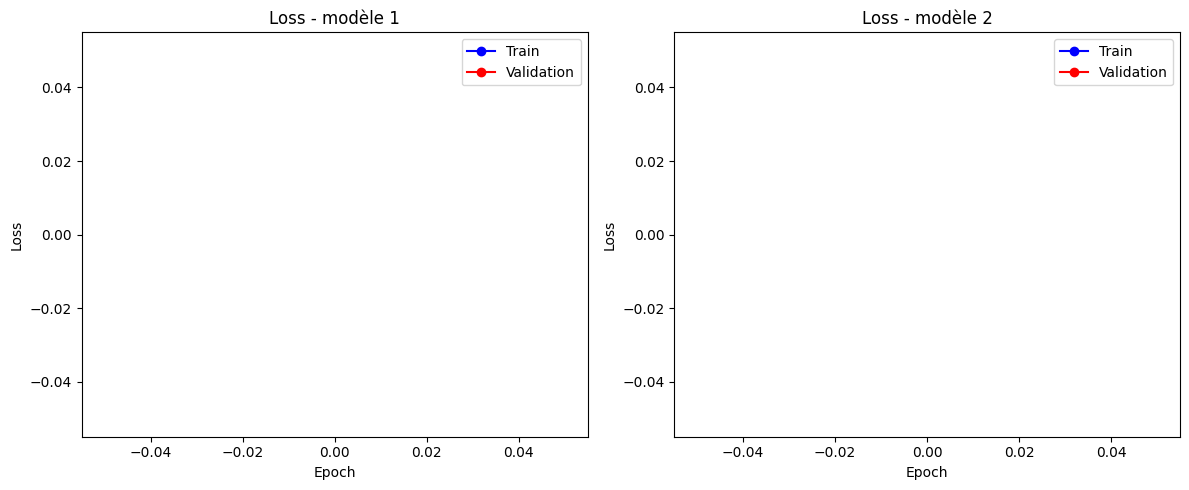

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Log 1
axes[0].plot(df_log1["epoch"], df_log1["train_loss"], marker='o', color="blue", label="Train")
axes[0].plot(df_log1["epoch"], df_log1["val_loss"], marker='o', color="red", label="Validation")
axes[0].set_title(f"Loss - {nom_modele_1}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()


# Log 2
axes[1].plot(df_log2["epoch"], df_log2["train_loss"], marker='o', color="blue", label="Train")
axes[1].plot(df_log2["epoch"], df_log2["val_loss"], marker='o', color="red", label="Validation")
axes[1].set_title(f"Loss - {nom_modele_2}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()


plt.tight_layout()
plt.show()

### **1.2 F1-macro**

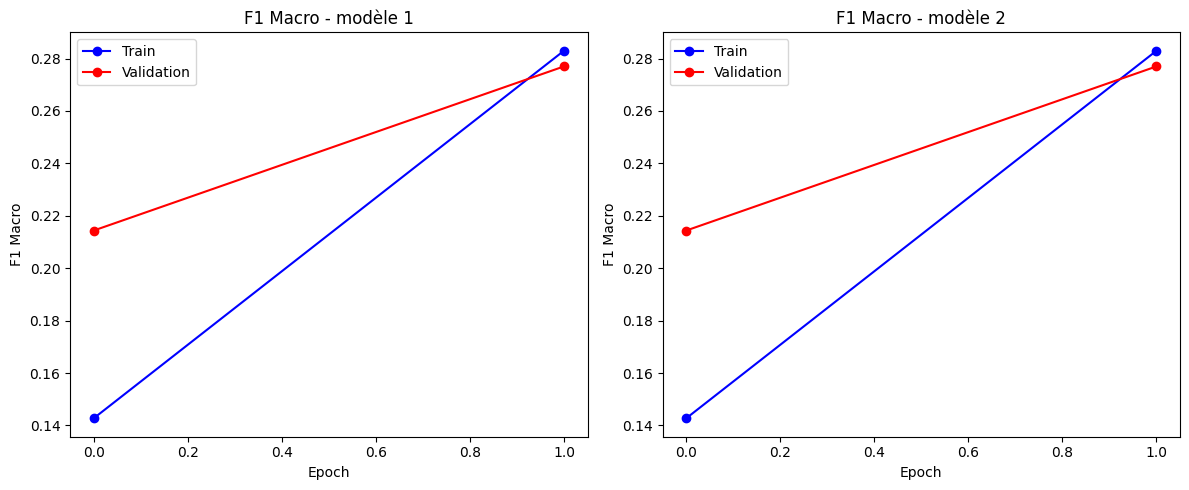

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Expérience 1
axes[0].plot(df_log1["epoch"], df_log1["train_f1_macro"], marker='o', color="blue", label="Train")
axes[0].plot(df_log1["epoch"], df_log1["val_f1_macro"], marker='o', color="red", label="Validation")
axes[0].set_title(f"F1 Macro - {nom_modele_1}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("F1 Macro")
axes[0].legend()


# Expérience 2
axes[1].plot(df_log2["epoch"], df_log2["train_f1_macro"], marker='o', color="blue", label="Train")
axes[1].plot(df_log2["epoch"], df_log2["val_f1_macro"], marker='o', color="red", label="Validation")
axes[1].set_title(f"F1 Macro - {nom_modele_2}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Macro")
axes[1].legend()


plt.tight_layout()
plt.show()

### **1.3 Evolution de la F1 par classe**

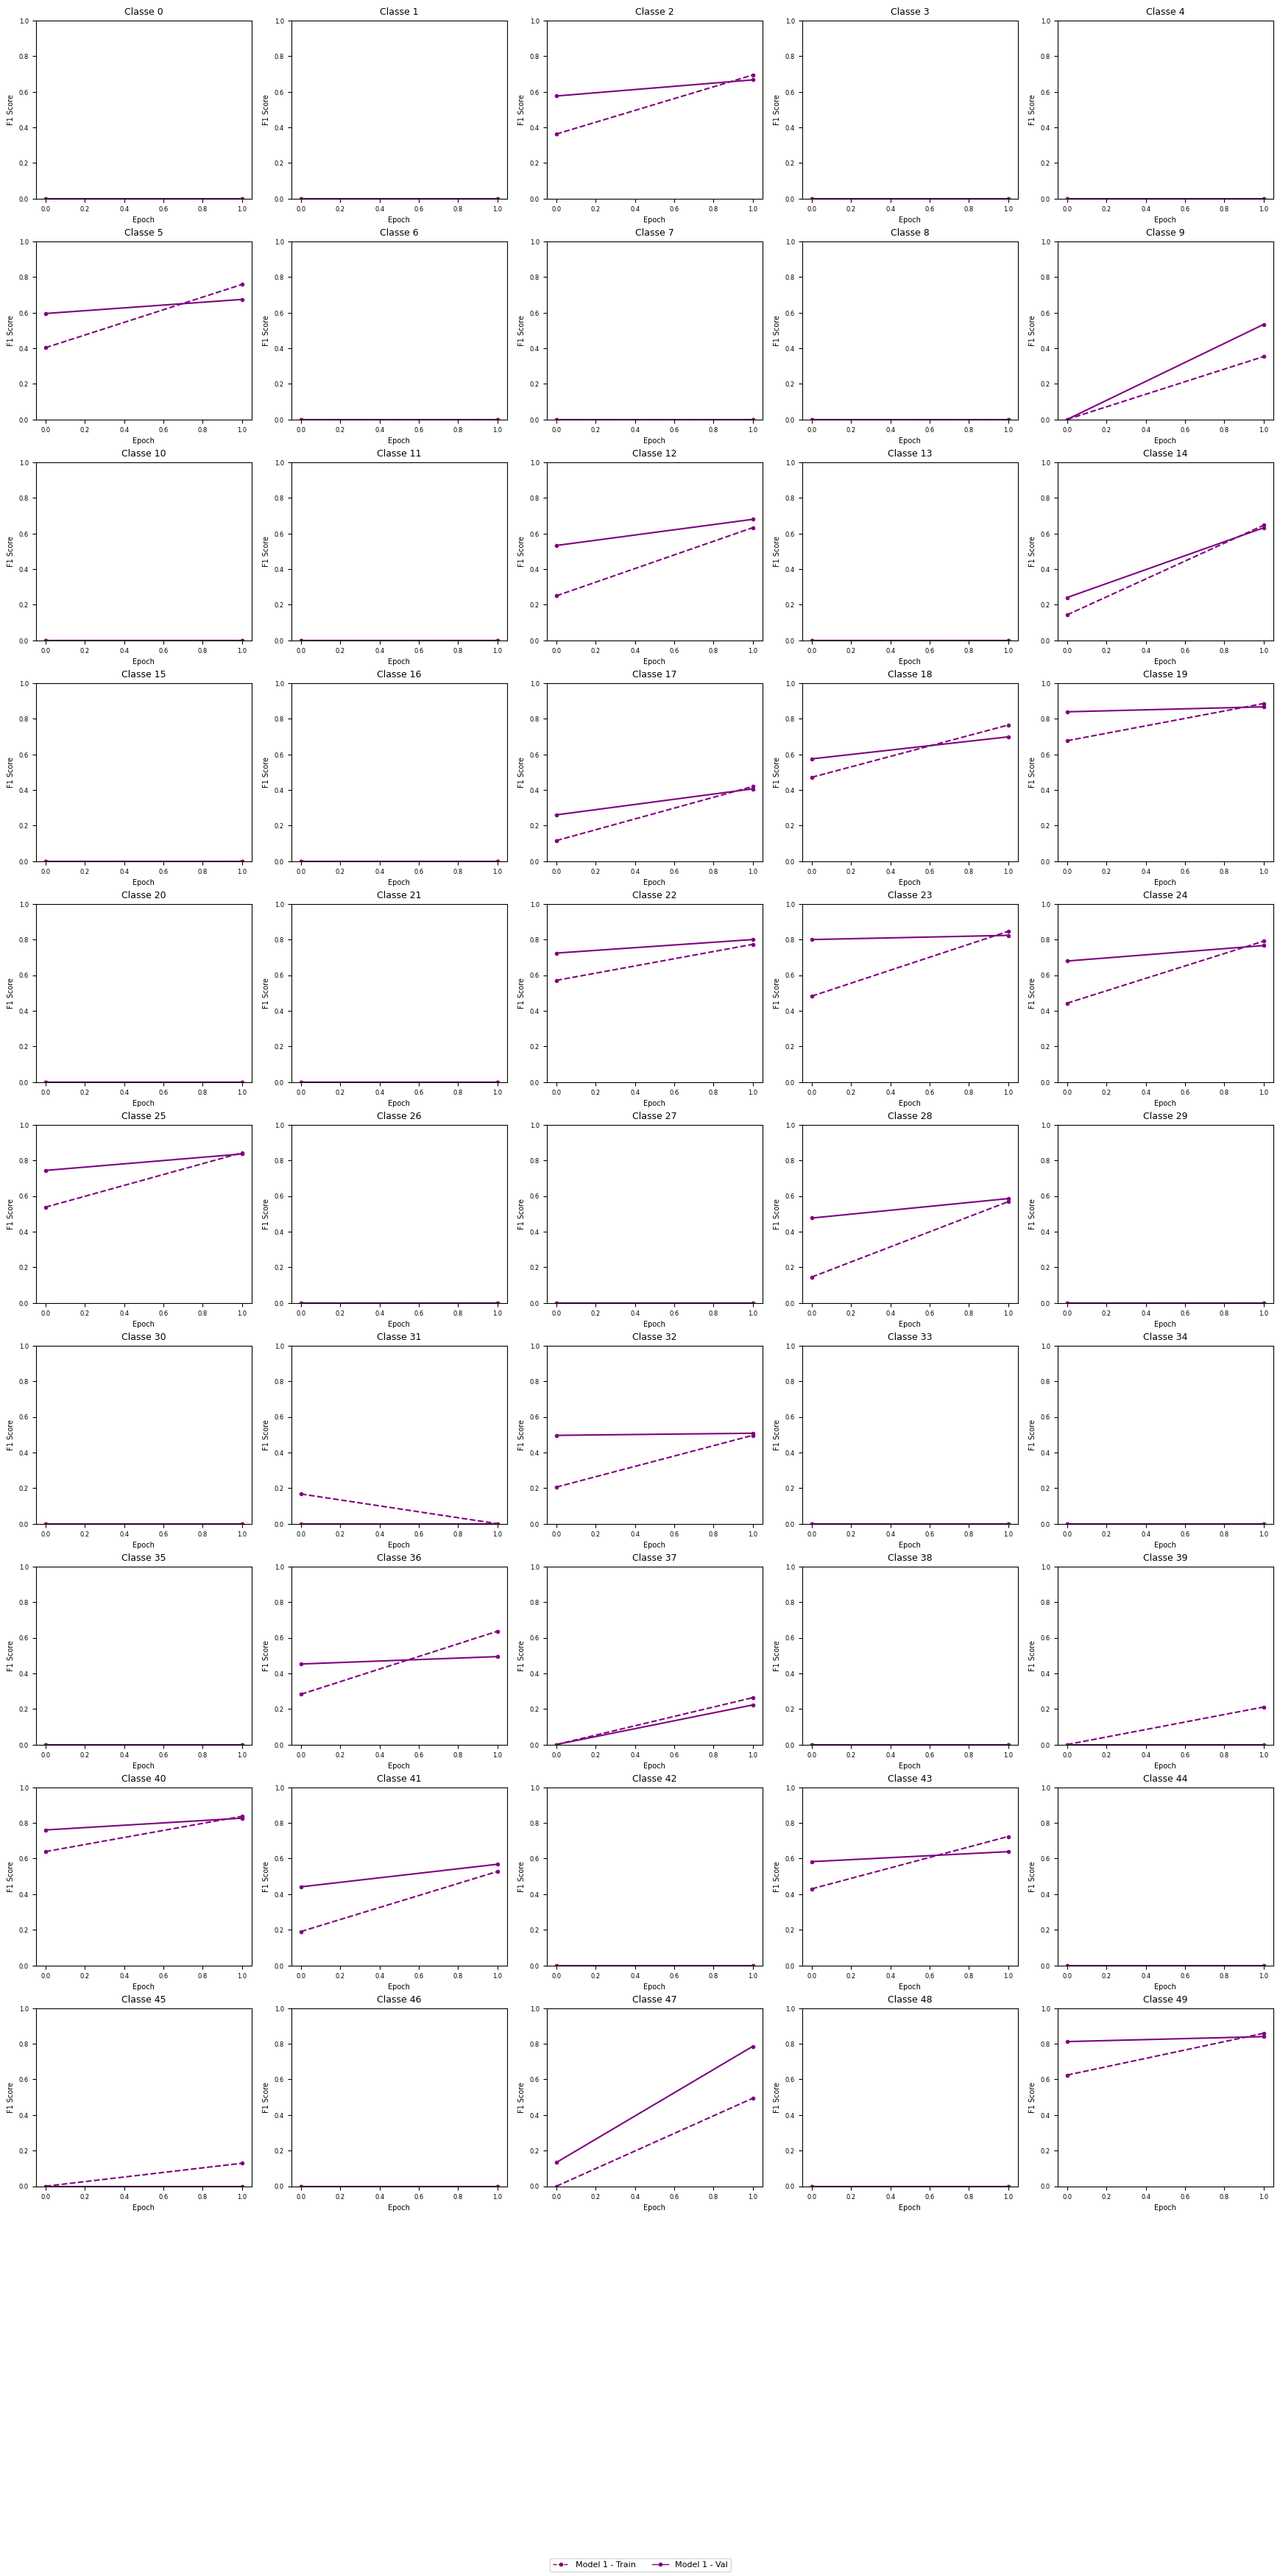

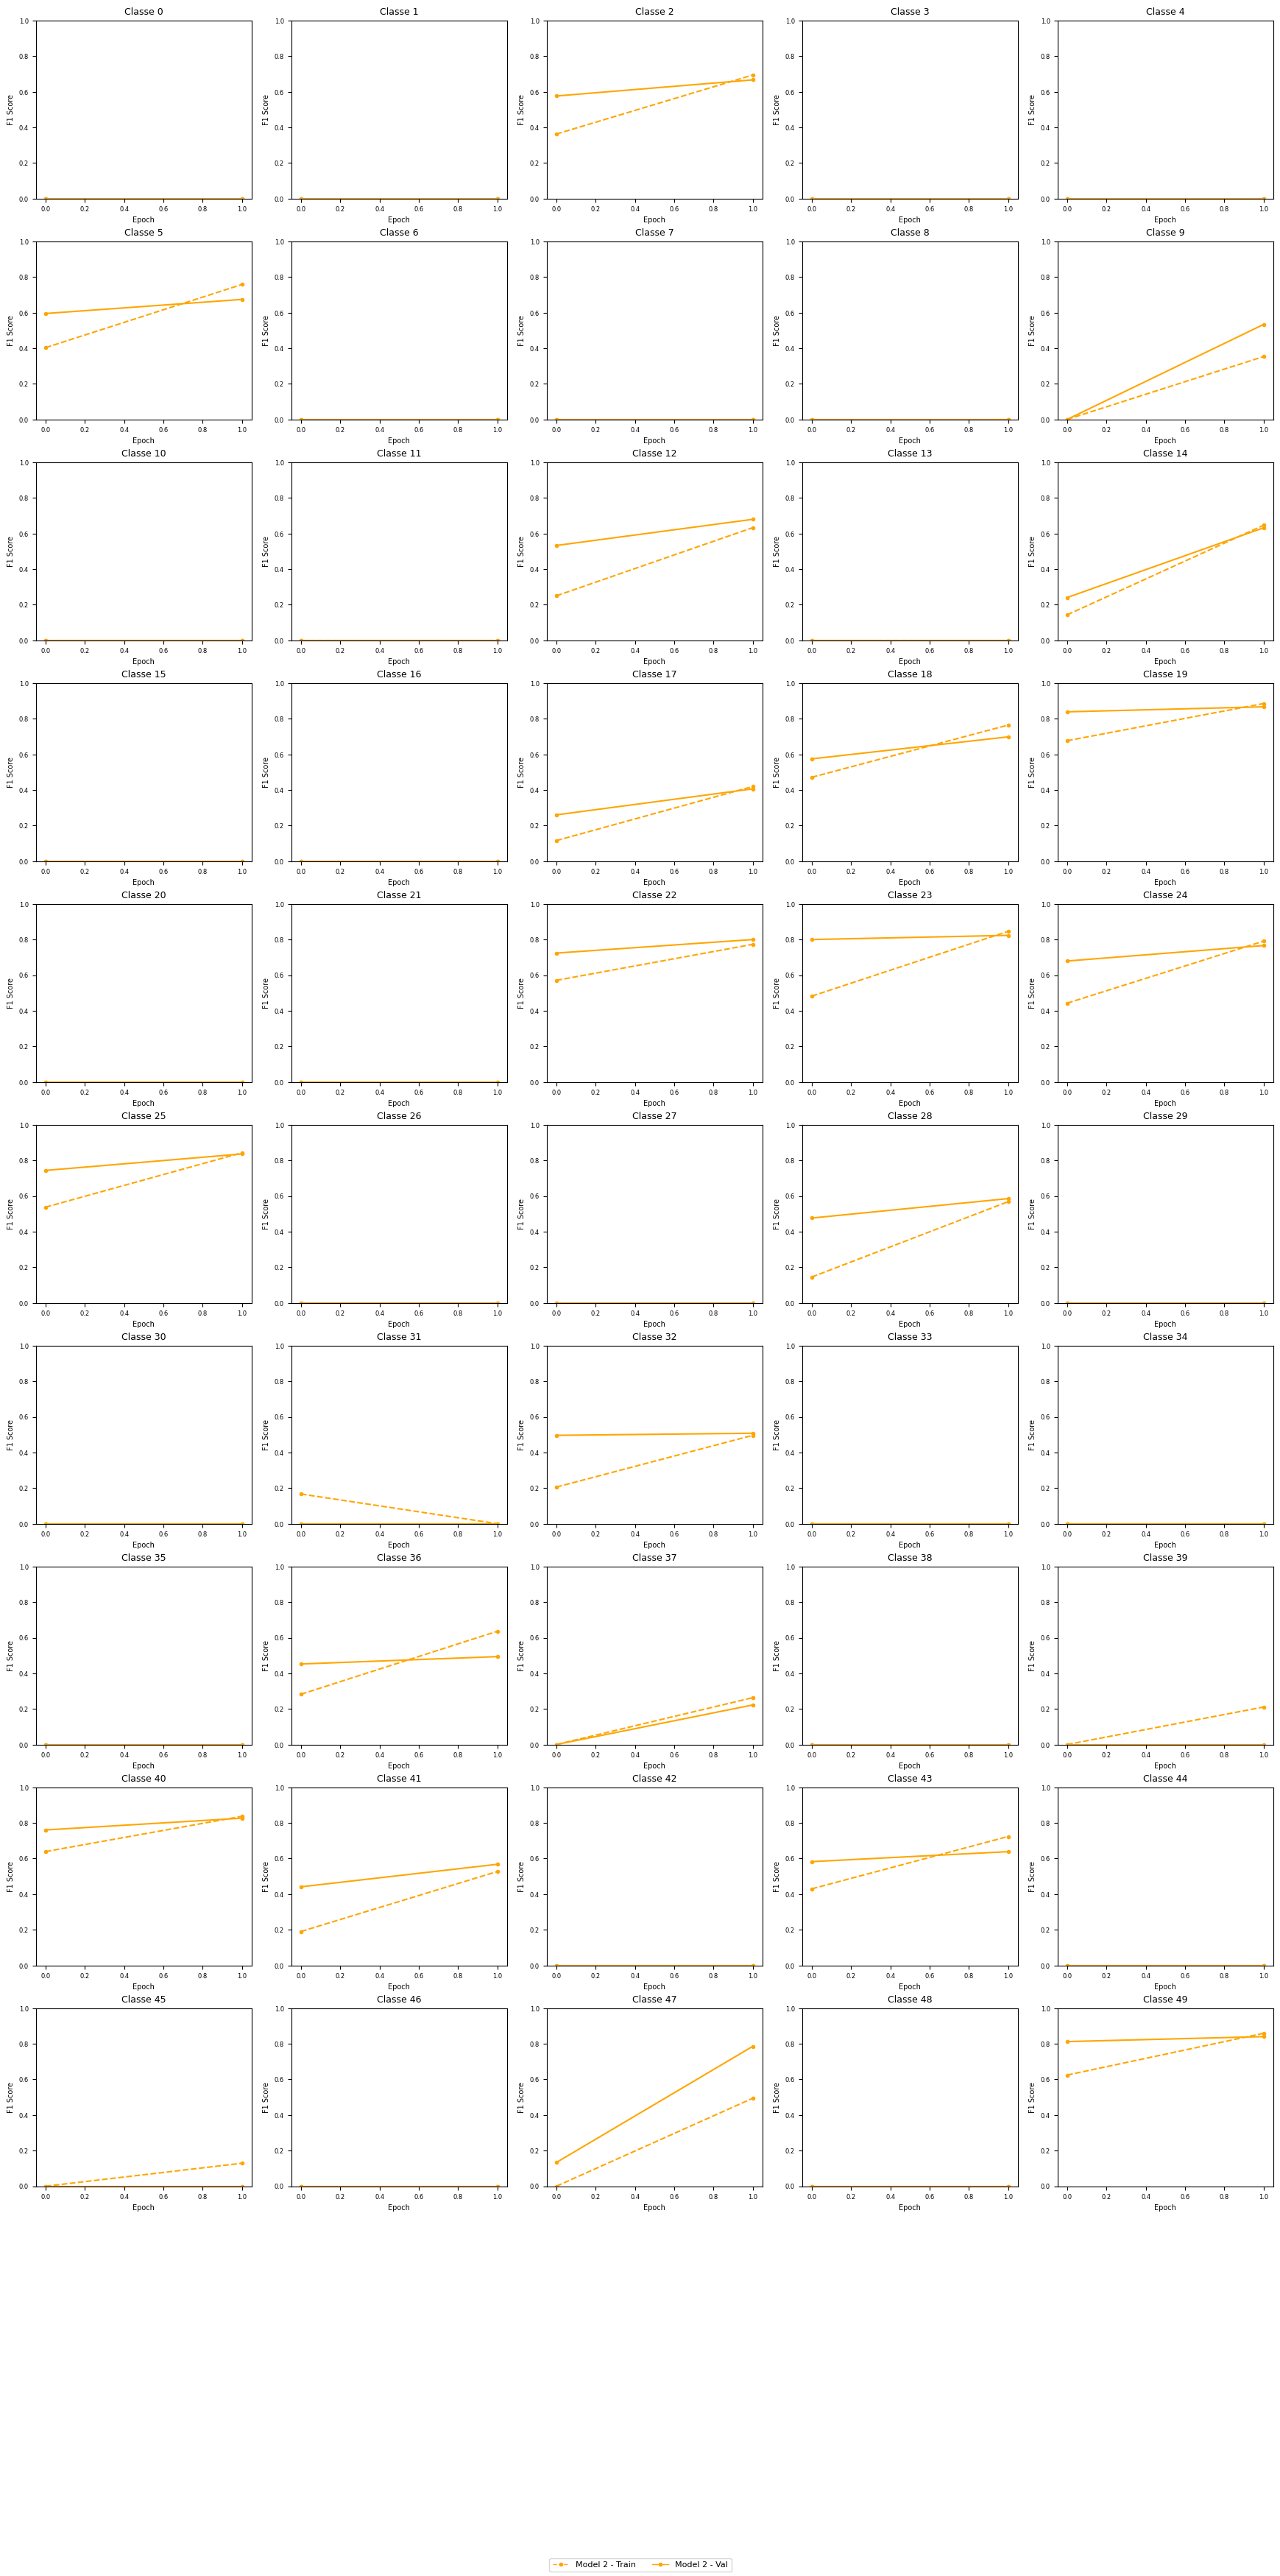

In [109]:
import matplotlib.pyplot as plt
import math

def plot_model_class_f1(df_metrics, model_name, color):
    num_classes = df_metrics['class'].nunique()
    cols = 5
    rows = math.ceil(num_classes / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*3.5))
    axes = axes.flatten()

    for cls in range(num_classes):
        ax = axes[cls]

        df_cls = df_metrics[df_metrics['class'] == cls]
        epochs = df_cls['epoch']
        train_f1 = df_cls['train_f1_score']
        val_f1 = df_cls['val_f1_score']

        # Train - pointillés
        ax.plot(epochs, train_f1, linestyle='--', color=color, marker='o', markersize=3,
                markerfacecolor=color, markeredgecolor=color)
        # Val - plein
        ax.plot(epochs, val_f1, linestyle='-', color=color, marker='o', markersize=3,
                markerfacecolor=color, markeredgecolor=color)

        ax.set_title(f'Classe {cls}', fontsize=9)
        ax.set_xlabel('Epoch', fontsize=7)
        ax.set_ylabel('F1 Score', fontsize=7)
        ax.set_ylim(0,1)
        ax.tick_params(axis='both', labelsize=6)

    # Supprimer axes vides si besoin
    for i in range(num_classes, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()

    # Légende unique pour cette figure
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=color, lw=1, marker='o', markersize=3, label=f'{model_name} - Train', linestyle='--'),
        Line2D([0], [0], color=color, lw=1, marker='o', markersize=3, label=f'{model_name} - Val', linestyle='-')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=8)
    plt.subplots_adjust(bottom=0.15)

    plt.show()


# Plot pour chaque modèle séparément
plot_model_class_f1(df_metrics_per_class_per_epoch_1, 'Model 1', 'purple')
plot_model_class_f1(df_metrics_per_class_per_epoch_2, 'Model 2', 'orange')

### **1.4 Accuracy**

In [110]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # Expérience 1
# axes[0].plot(df_log1["epoch"], df_log1["train_acc"], color="blue", label="Train")
# axes[0].plot(df_log1["epoch"], df_log1["val_acc"], color="red", label="Validation")
# axes[0].set_title("Accuracy - Expérience 1")
# axes[0].set_xlabel("Epoch")
# axes[0].set_ylabel("Accuracy")
# axes[0].legend()


# # Expérience 2
# axes[1].plot(df_log2["epoch"], df_log2["train_acc"], color="blue", label="Train")
# axes[1].plot(df_log2["epoch"], df_log2["val_acc"], color="red", label="Validation")
# axes[1].set_title("Accuracy - Expérience 2")
# axes[1].set_xlabel("Epoch")
# axes[1].set_ylabel("Accuracy")
# axes[1].legend()
# axes[1].grid(True)

# plt.tight_layout()
# plt.show()

## **2. Métriques liées à la meilleure performance**

### **2.1 Confusion matrix**

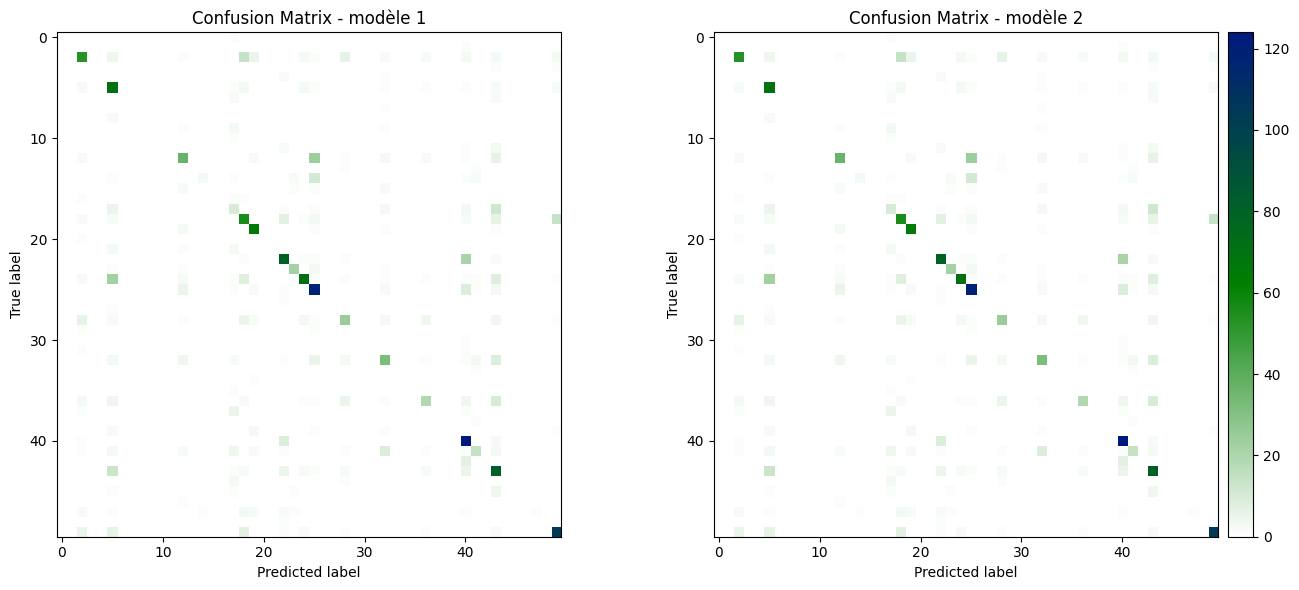

In [111]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

cm1 = df_confusion_matrix1.values
cm2 = df_confusion_matrix2.values

# Échelle commune
vmax = max(cm1.max(), cm2.max())

# Palette dégradée : bleu foncé -> vert -> blanc
colors = [ (1,1,1), (0,0.5,0), (0,0.1,0.5)]  # RGB tuples
cmap = LinearSegmentedColormap.from_list("custom_blue_green_white", colors, N=256)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Graphe 1 ---
im1 = axes[0].imshow(cm1, interpolation='nearest', vmin=0, vmax=vmax, cmap=cmap)
axes[0].set_title(f"Confusion Matrix - {nom_modele_1}")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

# --- Graphe 2 ---
im2 = axes[1].imshow(cm2, interpolation='nearest', vmin=0, vmax=vmax, cmap=cmap)
axes[1].set_title(f"Confusion Matrix - {nom_modele_2}")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

# --- Colorbar à droite ---
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im2, cax=cax)

plt.tight_layout()
plt.show()

### **2.2 Analyse du F1-score par classe**

In [112]:
df_val_counts = pd.read_csv("val_class_counts.csv")
df_val_counts = df_val_counts.sort_values("num_images")  # tri par nombre d'images

# Récupérer les classes et le nombre d'images
classes = df_val_counts['class'].values
num_images = df_val_counts['num_images'].values

**Rappel du nombre d'image par classe**

In [113]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# import os

# # Construire le chemin relatif
# csv_path = os.path.join("..","data", "train_corrected.csv")
# df = pd.read_csv(csv_path)

# # Compter le nombre d'images par classe
# class_counts = df['label'].value_counts().sort_index()

# # Normaliser pour la couleur
# norm = class_counts / class_counts.max()
# colors = cm.viridis(norm)  # dégradé bleu foncé -> vert -> jaune clair

# plt.figure(figsize=(18,6))
# plt.bar(class_counts.index, class_counts.values, color=colors)
# plt.xticks(class_counts.index, rotation=90)
# plt.ylabel("Nombre d'images")
# plt.xlabel("Classe")
# plt.title("Nombre d'images par classe dans le dataset d'entraînement")

# # Optionnel : ajouter une légende avec gradient
# sm = cm.ScalarMappable(cmap='viridis')
# sm.set_array(class_counts.values)
# cbar = plt.colorbar(sm)
# cbar.set_label("Nombre d'images (échelle couleur)")

# plt.show()

#### **Nombre d'images par classe et F1 score**

**Sur le dataset TRAINING** 

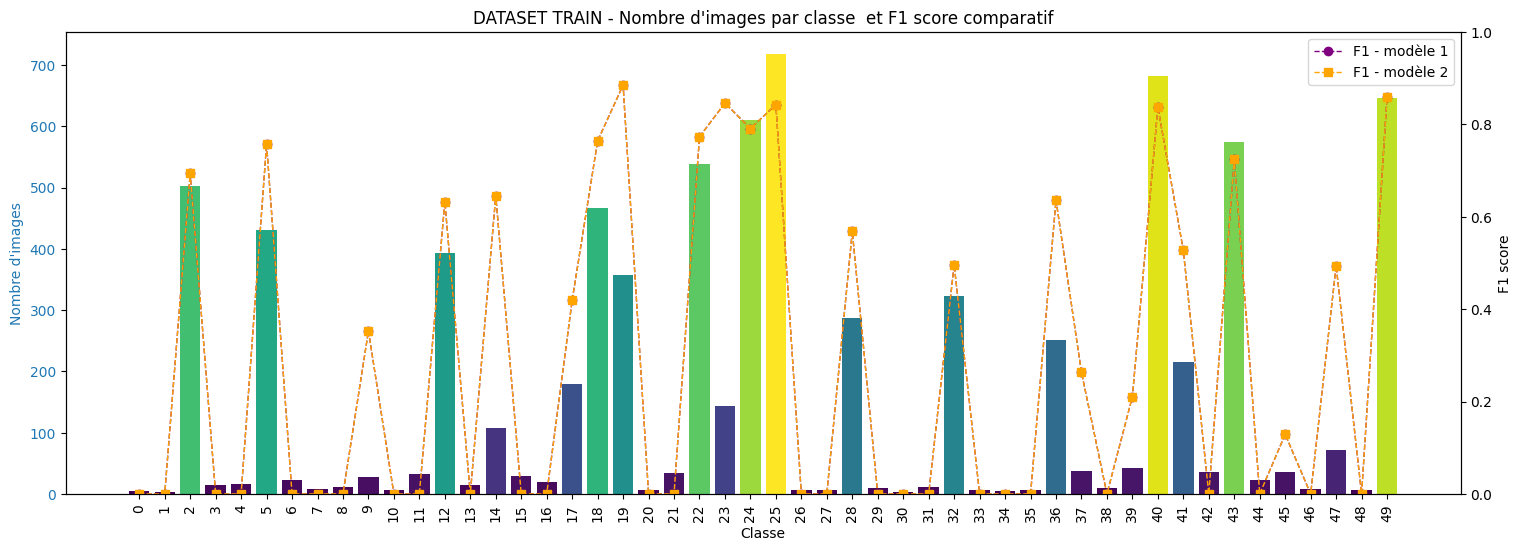

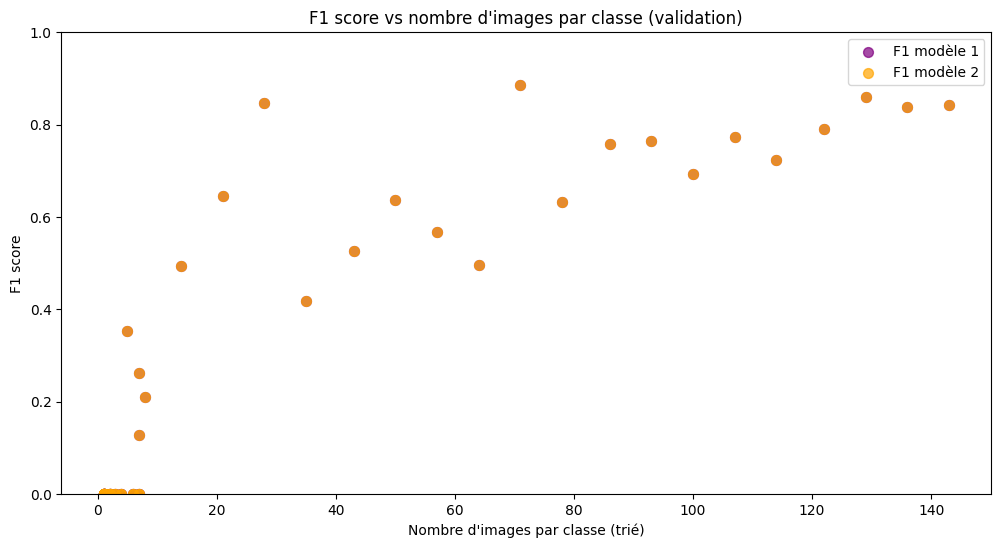

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import numpy as np

# --- Charger le CSV du dataset pour le nombre d'images ---
csv_path = os.path.join("..","data", "train_corrected.csv")
df = pd.read_csv(csv_path)

# Compter le nombre d'images par classe
class_counts = df['label'].value_counts().sort_index()



df_metrics1 = df_metrics_per_class1.sort_values("class")
df_metrics2 = df_metrics_per_class2.sort_values("class")

f1_exp1 = df_metrics1['train_f1_score'].values
f1_exp2 = df_metrics2['train_f1_score'].values


classes = class_counts.index

# --- Palette couleur pour les barres selon nombre d'images ---
norm = class_counts / class_counts.max()
colors = cm.viridis(norm)

# --- Création du graphique ---
fig, ax1 = plt.subplots(figsize=(18,6))

# Barres : nombre d'images par classe
bars = ax1.bar(classes, class_counts.values, color=colors, label='Nombre d\'images')
ax1.set_xlabel("Classe")
ax1.set_ylabel("Nombre d'images", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(classes)
ax1.set_xticklabels(classes, rotation=90)

# Axe secondaire pour F1 scores
ax2 = ax1.twinx()
ax2.plot(classes, f1_exp1, color='purple', marker='o', linestyle='--', linewidth=1, label=f'F1 - {nom_modele_1}')
ax2.plot(classes, f1_exp2, color='orange', marker='s', linestyle='--', linewidth=1, label=f'F1 - {nom_modele_2}')
ax2.set_ylabel("F1 score", color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0, 1)  # F1 entre 0 et 1

# Légende combinée
lines_labels = [ax2.get_legend_handles_labels()]
lines, labels = [], []
for lh, lb in lines_labels:
    lines += lh
    labels += lb
ax2.legend(lines, labels, loc='upper right')

plt.title("DATASET TRAIN - Nombre d'images par classe  et F1 score comparatif")


# Charger le CSV du nombre d'images par classe
df_val_counts = pd.read_csv("val_class_counts.csv")
df_val_counts = df_val_counts.sort_values("num_images")  # tri par nombre d'images

# Récupérer les classes et le nombre d'images
classes = df_val_counts['class'].values
num_images = df_val_counts['num_images'].values

# F1 scores triés dans le même ordre que num_images
df_metrics1_sorted = df_metrics_per_class1.set_index('class').loc[classes]
df_metrics2_sorted = df_metrics_per_class2.set_index('class').loc[classes]

f1_train1 = df_metrics1_sorted['train_f1_score'].values
f1_train2 = df_metrics2_sorted['train_f1_score'].values

# Création du graphique
plt.figure(figsize=(12,6))
plt.scatter(num_images, f1_train1, color='purple', label=f'F1 {nom_modele_1}', s=50, alpha=0.7)
plt.scatter(num_images, f1_train2, color='orange', label=f'F1 {nom_modele_2}', s=50, alpha=0.7)

# Optionnel : relier chaque classe pour voir la différence entre Exp1 et Exp2
for i in range(len(num_images)):
    plt.plot([num_images[i], num_images[i]], [f1_train1[i], f1_train2[i]], color='gray', linestyle=':', linewidth=0.8)

plt.xlabel("Nombre d'images par classe (trié)")
plt.ylabel("F1 score")
plt.title("F1 score vs nombre d'images par classe (validation)")
plt.ylim(0,1)
plt.legend()

plt.show()


**Sur le dataset VALIDATION**

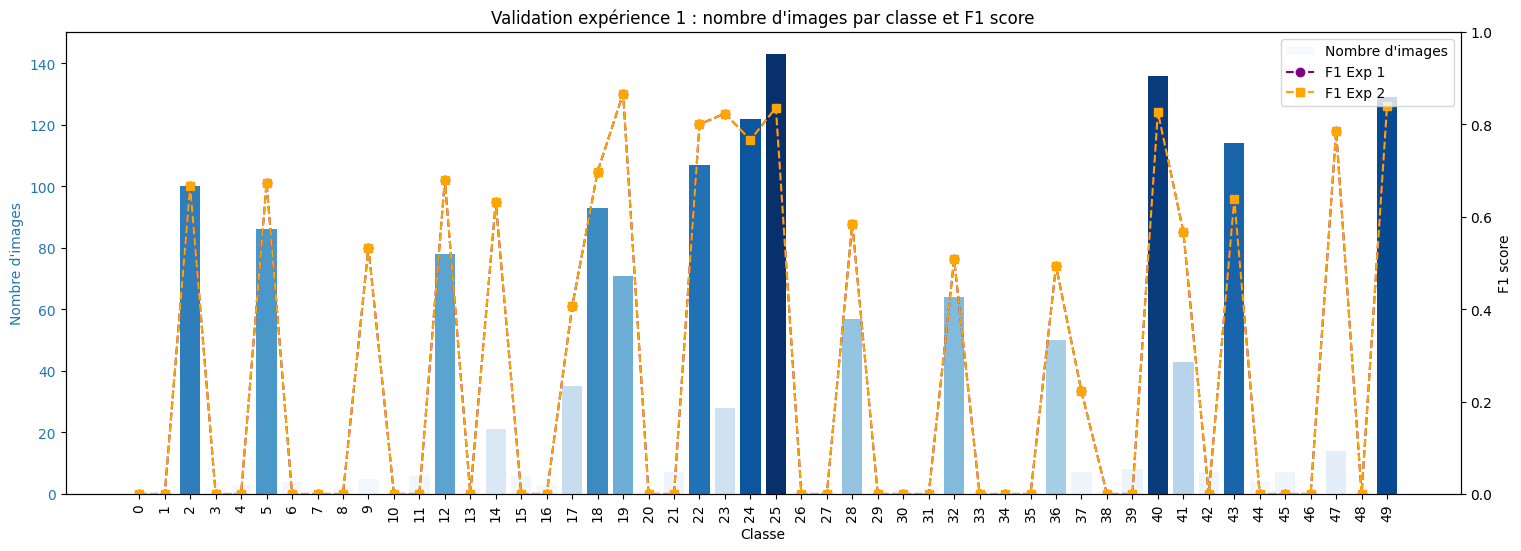

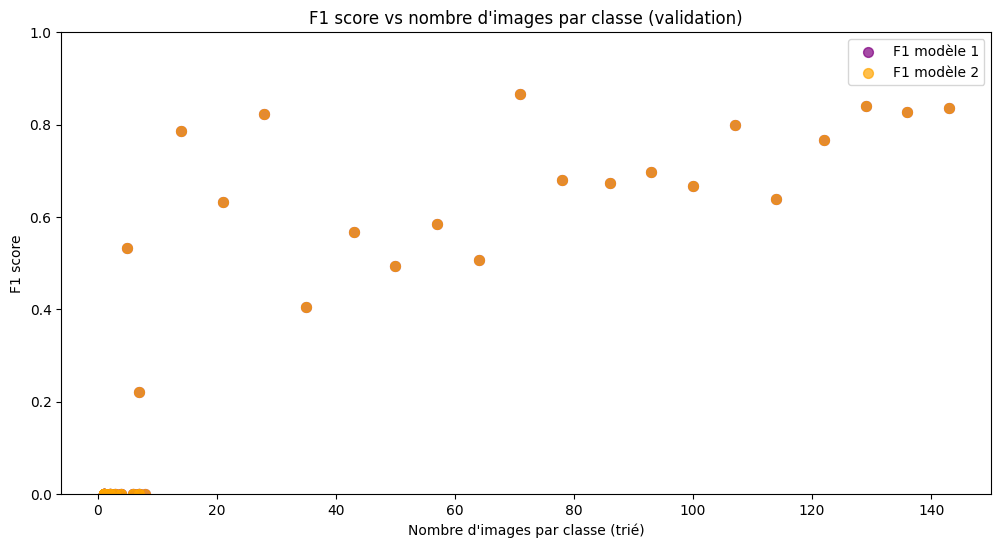

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import os
import csv



# Charger le CSV pour plotting
df_val_counts = pd.read_csv("val_class_counts.csv")
df_val_counts = df_val_counts.sort_values("class")
classes = df_val_counts['class'].values
num_images = df_val_counts['num_images'].values

# --- Étape 2 : récupérer les F1 scores pour deux expériences ---
df_metrics1 = df_metrics_per_class1.sort_values("class")
df_metrics2 = df_metrics_per_class2.sort_values("class")

f1_exp1 = df_metrics1['val_f1_score'].values
f1_exp2 = df_metrics2['val_f1_score'].values


# --- Étape 3 : palette couleur pour le nombre d'images ---
norm = num_images / num_images.max()
colors = cm.Blues(norm)  # dégradé bleu foncé -> clair selon nombre d'images

# --- Étape 4 : création du graphique ---
fig, ax1 = plt.subplots(figsize=(18,6))

# Barres : nombre d'images par classe
bars = ax1.bar(classes, num_images, color=colors, label="Nombre d'images")
ax1.set_xlabel("Classe")
ax1.set_ylabel("Nombre d'images", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(classes)
ax1.set_xticklabels(classes, rotation=90)

# Axe secondaire pour F1 scores
ax2 = ax1.twinx()
ax2.plot(classes, f1_exp1, color='purple', marker='o', linestyle='--', linewidth=1.5, label='F1 Exp 1')
ax2.plot(classes, f1_exp2, color='orange', marker='s', linestyle='--', linewidth=1.5, label='F1 Exp 2')
ax2.set_ylabel("F1 score", color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0,1)

# Légende combinée
lines_labels = [ax1.get_legend_handles_labels(), ax2.get_legend_handles_labels()]
lines, labels = [], []
for lh, lb in lines_labels:
    lines += lh
    labels += lb
ax2.legend(lines, labels, loc='upper right')

plt.title("Validation expérience 1 : nombre d'images par classe et F1 score")






# F1 scores triés dans le même ordre que num_images
df_metrics1_sorted = df_metrics_per_class1.set_index('class').loc[classes]
df_metrics2_sorted = df_metrics_per_class2.set_index('class').loc[classes]

f1_val1 = df_metrics1_sorted['val_f1_score'].values
f1_val2 = df_metrics2_sorted['val_f1_score'].values

# Création du graphique
plt.figure(figsize=(12,6))
plt.scatter(num_images, f1_val1, color='purple', label=f'F1 {nom_modele_1}', s=50, alpha=0.7)
plt.scatter(num_images, f1_val2, color='orange', label=f'F1 {nom_modele_2}', s=50, alpha=0.7)

# Optionnel : relier chaque classe pour voir la différence entre Exp1 et Exp2
for i in range(len(num_images)):
    plt.plot([num_images[i], num_images[i]], [f1_val1[i], f1_val2[i]], color='gray', linestyle=':', linewidth=0.8)

plt.xlabel("Nombre d'images par classe (trié)")
plt.ylabel("F1 score")
plt.title("F1 score vs nombre d'images par classe (validation)")
plt.ylim(0,1)
plt.legend()

plt.show()


**TRAIN vs VALIDATION**

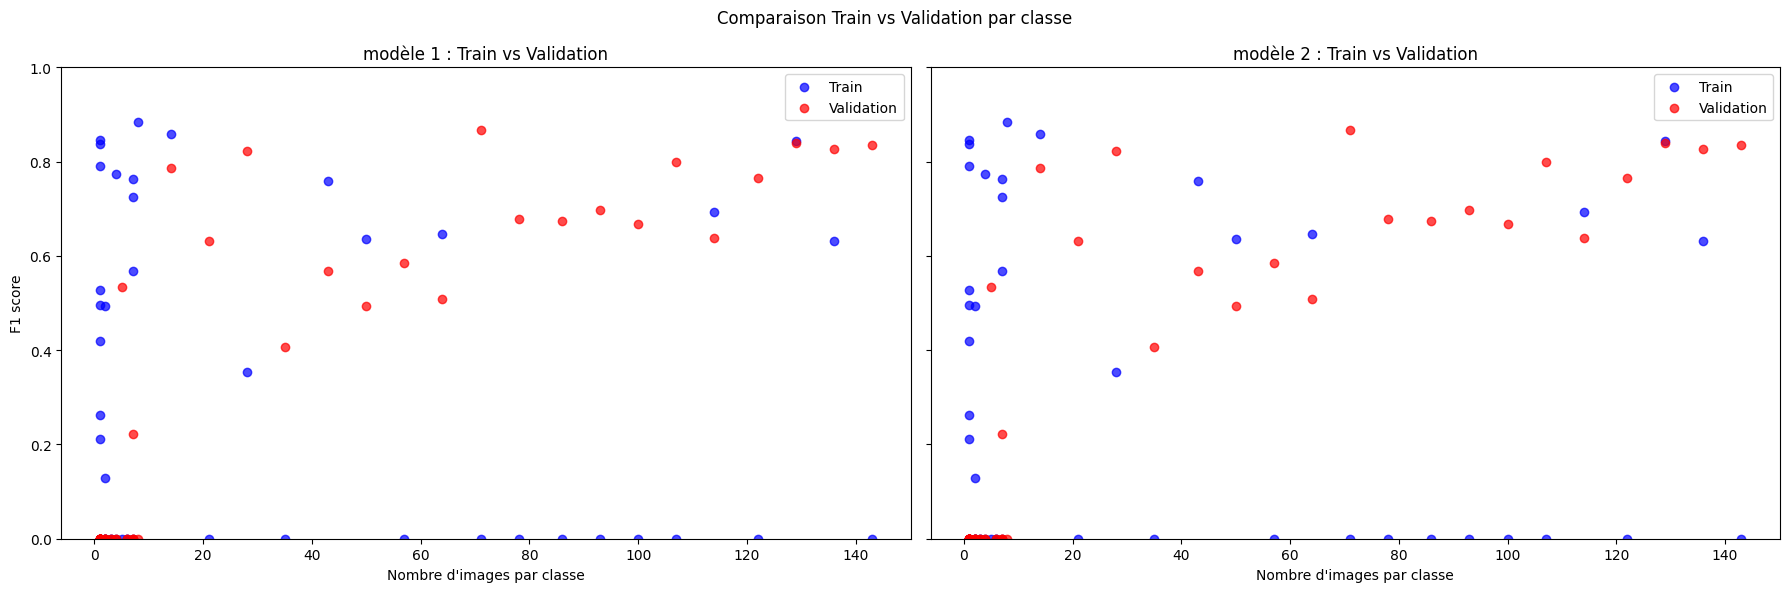

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)

# ===== MODELE 1 =====
axes[0].scatter(num_images, f1_train1, label='Train', alpha=0.7, color='blue')
axes[0].scatter(num_images, f1_val1, label='Validation', alpha=0.7, color='red')

axes[0].set_title(f"{nom_modele_1} : Train vs Validation")
axes[0].set_xlabel("Nombre d'images par classe")
axes[0].set_ylabel("F1 score")
axes[0].set_ylim(0,1)
axes[0].legend()

# ===== MODELE 2 =====
axes[1].scatter(num_images, f1_train2, label='Train', alpha=0.7, color ='blue')
axes[1].scatter(num_images, f1_val2, label='Validation', alpha=0.7, color='red')

axes[1].set_title(f"{nom_modele_2} : Train vs Validation")
axes[1].set_xlabel("Nombre d'images par classe")
axes[1].set_ylim(0,1)
axes[1].legend()

plt.suptitle("Comparaison Train vs Validation par classe")
plt.tight_layout()
plt.show()

F1 score **VALIDATION** et **TEST** pour chaque classe (Antonin)

### **2.3 Comparaison des autres metriques**

**Validation**

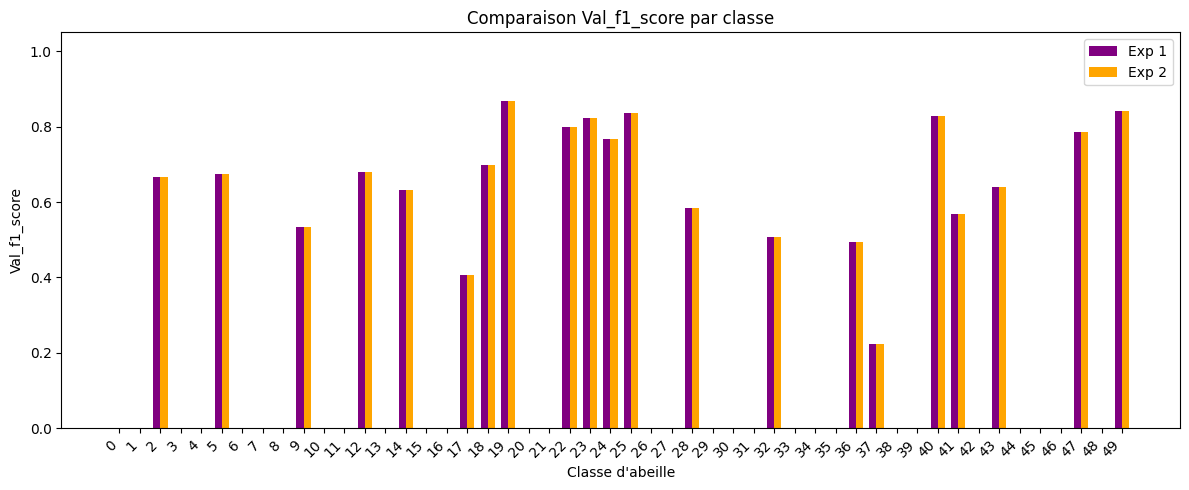

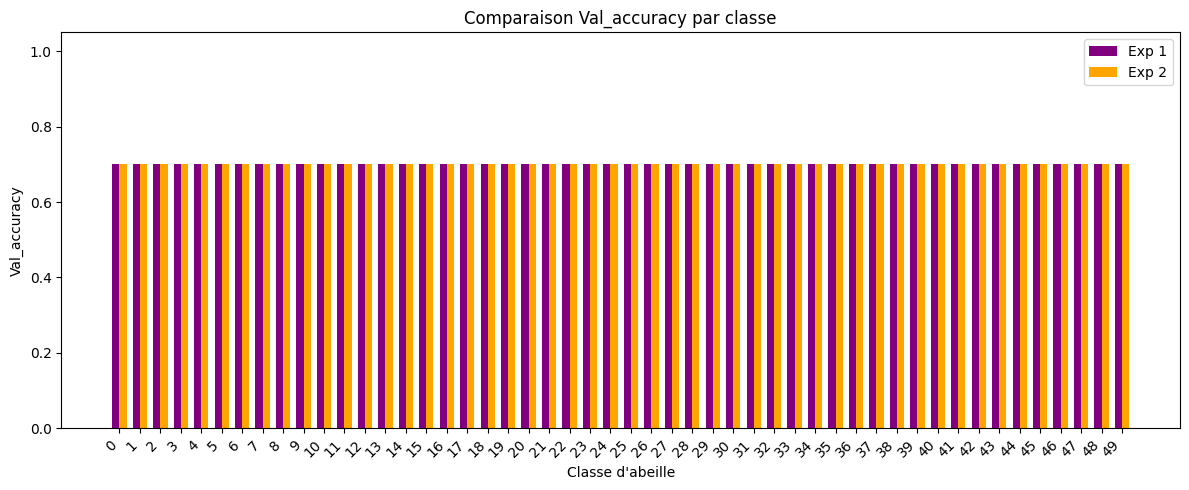

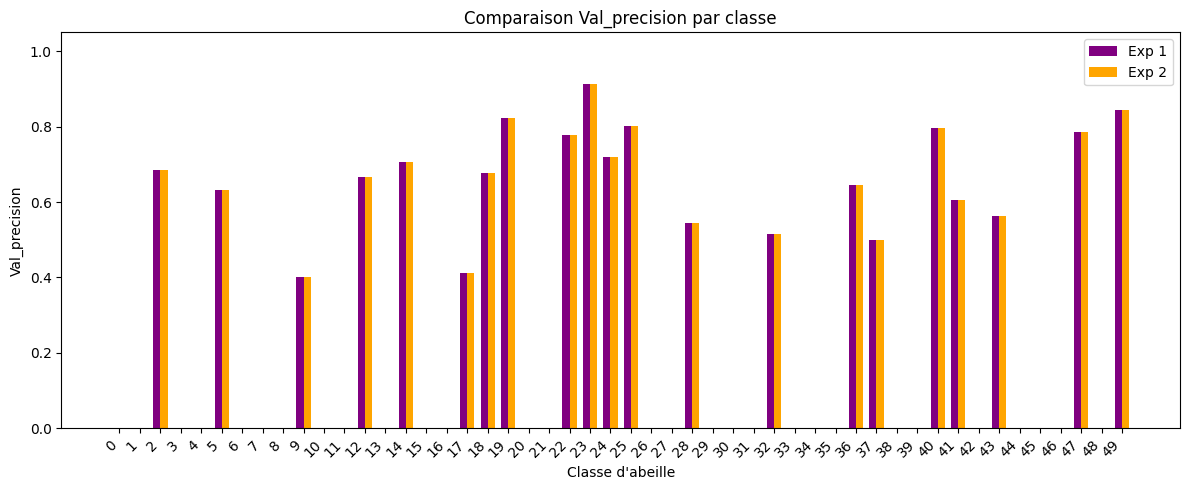

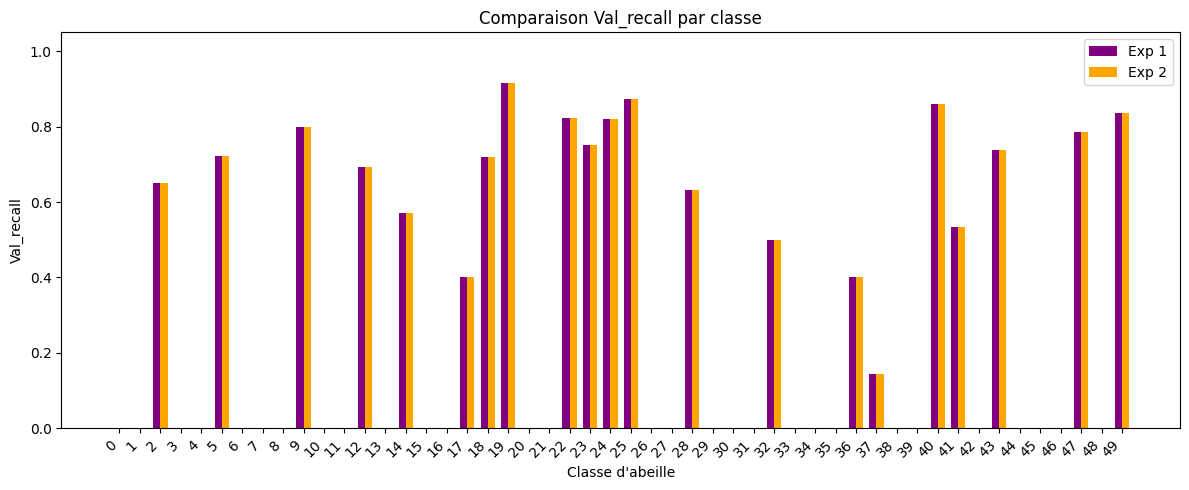

In [118]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np



classes = df_metrics_per_class1['class']  # ou juste df_metrics1['class'] si présente

metrics = ["val_f1_score","val_accuracy", "val_precision", "val_recall"]

for metric in metrics:
    values1 = df_metrics_per_class1[metric].values
    values2 = df_metrics_per_class2[metric].values

    x = np.arange(len(classes))
    width = 0.35  # largeur des barres

    fig, ax = plt.subplots(figsize=(12,5))
    ax.bar(x - width/2, values1, width, label="Exp 1", color='purple')
    ax.bar(x + width/2, values2, width, label="Exp 2", color='orange')

    ax.set_xlabel("Classe d'abeille")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"Comparaison {metric.capitalize()} par classe")
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_ylim(0,1.05)  # toutes les métriques sont entre 0 et 1

    ax.legend()
    plt.tight_layout()
    plt.show()

## **3. Autres plots** 